Neuromorphic engineering I

## Lab 11: Silicon Neuron Circuits

Team member 1: 

Team member 2: 

Date:

-------------------------------------------------------------------------------------------------------------------

In this lab, we will test a circuit that generates action potentials (spikes) based on an
integrate-and-fire model of a neuron spike initiation zone.

The objectives of this lab are:
1. to understand the spiking properties of I&F circuits.
2. to evaluate the effect of the I&F circuit’s different bias parameters on its spiking behaviour.

# 1 Reading

Please see the [neuron lecture slides](https://docs.google.com/presentation/d/1n1FAI_8s_7JPn4GEgO0dsFb_BAjL3JsV/edit?usp=sharing&ouid=100322739603781784146&rtpof=true&sd=true).
* The Axon-Hillock circuit is first described in [Mead Analog VLSI and Neural Systems: book chapter 4](https://drive.google.com/file/d/0BzvXOhBHjRheVlp6V052ekJOTzg/view?usp=sharing&resourcekey=0-AO8Y3WI8cx4lRlqz-rB5dQ). 
* The low power **ADEXIF** (Adaptive Exponential Integrate & Fire) neuron circuit is first disclosed in [this 2009 paper](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=5118408). 

# 2 Prelab

<div id="fig:02:wta-schematic"
    style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">
    
![Axon-Hillock](figs/axon-hillock.png)

**Figure 1**: schematic of an Axon-Hillock Neuron circuit

</div>

<font color=#108ee9> 

* Sketch the diagram of $V_{\rm mem}$ and $V_{out}$ given a costant input current $I_{in} = 0.5$nA, a reset current $I_{rst} = 1.5$nA, $\text{VDD} = 1.5$V and $\text{VSS} = 0$V. 
 
</font>

Consider a value of $C_{\text{mem}} = 1nF$. Pay close attention to the slopes of the traces you draw. Ignore, for now, the peak value of $V_{\text{mem}}$.

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">



</div>

<font color=#108ee9> 

* What is the peak value that $V_{\rm mem}$ reaches? 

</font>


Consider the values $C_{\text{fb}} = 810$ fF and $C_{\text{mem}} = 2$ pF 

(*N.B. these are the actual values on the CoACH board*) and $V_{\rm thr} = 0.5$ V.

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">


</div>

* <font color=#108ee9> What is the resulting rising-edge spike frequency? </font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">


</div>

* <font color=#108ee9> How does the output frequency grow with input current? </font>
Do you think this circuit would be able to measure a current of 1mA?

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">


</div>

<font color=#108ee9> 

* How much charge $Q$ is required to generate a single spike?
 </font>

 This result should be expressed in terms of Vdd and one or more capacitance values. The result might surprise you; it shows how this neuron circuit is  precise because it does not depend on any transistor parameters (if you can assume that the reset is much shorter than the neuron spike period).

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

</div>

# 3 Setup

Import necessary python libraries. The cell below may be collapsed.

In [1]:
import time # for time.sleep(seconds)
import numpy as np # numpy for arrays etc
from scipy import stats, interpolate, signal # for stats.linregress
import matplotlib
import matplotlib.pyplot as plt # for plotting
import matplotlib
plt.rcParams.update({'font.size': 10}) # make the detault font size larger for your readers
matplotlib.rcParams['pdf.fonttype'] = 42 # save fonts as type that are not outlined in illustrator or other drawing programs
from engineering_notation import EngNumber as ef # format numbers in engineering format quickly, e.g. ef(2e-9)='2n' https://pypi.org/project/engineering-notation/
from pathlib import Path # used for saving data

datapath = Path('data/neuron') # make a data folder to save your data called data/lab5
datapath.mkdir(parents=True, exist_ok=True)
from jupyter_save_load_vars import savevars, loadvars
from tqdm import tqdm

from IPython.display import display, Markdown, Latex, clear_output

import pyplane # for type hinting of biasgen constants
from ne1 import Coach # import Coach() class
import logging
# below lines are notebook magic for debugging, you can uncomment them when debugging the Coach() class
# %load_ext autoreload
# %autoreload explicit
# %aimport ne1

In [2]:
# create a Plane object and open the communication
c=Coach(logging_level=logging.INFO) # NOTE change to INFO to reduce clutter - create a Coach object called p; you will use it to talk to class chip, change to logging.DEBUG for troubleshooting
c.open()

[INFO]: 2025-11-17 09:50:25,205 - NE1 - Opened CoACH at /dev/cu.usbmodem76207501 with firmware version (1, 12, 5) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 175, in open)


## 3.1 Chip configuration

In [3]:
c.setup_ahn()

[INFO]: 2025-11-17 09:50:29,053 - NE1 - setup AHN (axon hillock neuron) (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 1598, in setup_ahn)


# 3 Axon-Hillock neuron

The axon-hillock neuron has a constant current input `AHN_IIN_UI` which is about pA (exact value not known), and the voltage on capacitor $C_m$ is output to **ADC[11]**.

<div id="fig:02:wta-schematic"
    style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">
    
![CoACH Axon-Hillock](figs/axon-hillock-coach.png)

**Figure 2**: schematic of the Axon-Hillock neuron (AHN) circuit present on the CoACH board

**$$
\begin{alignedat}{3}
& V_{\rm mem}  && = {\rm ADC[11]}
\\
& I_{\rm in} && = {\rm AHN\_IIN\_UI}
\end{alignedat}
$$**

</div>

## 3.1 Basic measurement

* With `Coach.set_ahn_vpw_ib` we can directly set the reset current $I_{\rm rst}$.

In [5]:
Ib = c.set_ahn_vpw_ib(pyplane.Coach.BiasGenMasterCurrent.I60pA, 2)
display(Markdown(f" $I_{{\\rm rst}} = $ {ef(Ib)}A"))

 $I_{\rm rst} = $ 1.41pA

* Constant input current is always applied to the circuit. To measure the circuit
response now we just need to sample the $V_{\rm mem}$ voltage. To do this, the
`Coach.read_ahn_vout()` method is used.

In [6]:
N_samples = 150
dT = 0.03

t = np.arange(N_samples)*dT
Vcm = np.zeros(N_samples) # v_Cm

for i in tqdm(range(N_samples)):
    Vcm[i] = c.read_ahn_vout()
    time.sleep(dT)

100%|██████████| 150/150 [00:05<00:00, 28.70it/s]


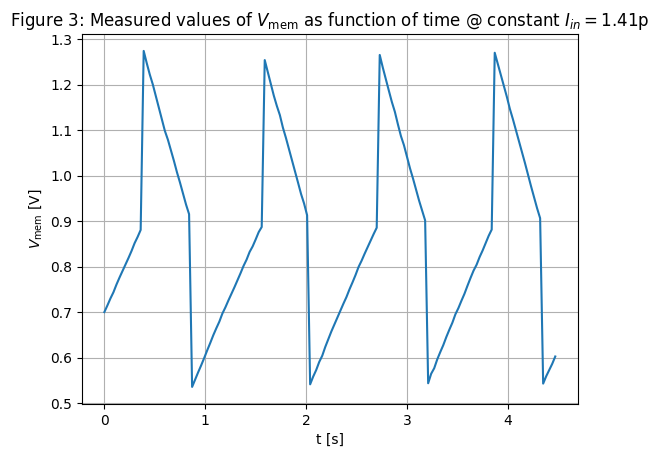

In [7]:
plt.plot(t, Vcm)
plt.xlabel('t [s]')
plt.ylabel('$V_{\\rm mem}$ [V]')
plt.title(f'Figure 3: Measured values of $V_{{\\rm mem}}$ as function of time @ constant $I_{{in}} = ${ef(Ib)}')
plt.grid()
plt.show()

In [11]:
# if the data looks nice, save it!
savevars(datapath/'3_1_ahn', overwrite=True)

[INFO]: 2025-11-17 09:58:05,150 - saveloadvars - Saved to data/neuron/3_1_ahn.dill variables [ datapath Ib N_samples dT t Vcm i ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-17 09:58:05,152 - saveloadvars - could not pickle: ['c'] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [9]:
# maybe you need to load your saved data?
loadvars(datapath/'ahn')

[INFO]: 2025-11-17 09:57:19,066 - saveloadvars - cancelled  loadvars from possibly unsafe dill (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 273, in loadvars)


* <font color=#108ee9> Can you estimate the threshold voltage value $V_{\rm thr}$ from the plot?
</font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

The plot seems to indicate a $V_{\rm thr} \approx 0.89V$.

</div>

    We can validate your answer with some simple python code

In [14]:
fun_thr = 0.1
discontinuities_idx = np.where(
    np.diff(Vcm) > fun_thr
)
# Calculate the indexes (np.where) where the difference between each subsequent sample
# (np.diff) is greater than a certain threshold (fun_thr = 0.1)
# We can now simply take the mean of the corresponding values
Vthr = np.mean(Vcm[discontinuities_idx])
display(Markdown(f"$V_{{\\rm thr}} = $ {ef(Vthr)}V"))

$V_{\rm thr} = $ 883.61mV

* <font color=#108ee9> Calculate the input current $I_{in}$ from the plot. </font>

In [15]:
Cmem = 2e-12

idx = int(0.6 // dT)
dvdt = (Vcm[idx] - Vcm[1]) / ((idx - 1)*dT)
Iin = Cmem * dvdt

display(Markdown(f"$I_{{in}} = $ {ef(Iin)}A"))

$I_{in} = $ 1.35pA

* <font color=#108ee9> Now calculate $I_{in}$ again, but use the inverse of the formula for
    $t_L$. 
  </font>
  Help yourself with the following code cell that finds the low and high peaks of the
  waveform and corresponding intervals.

In [17]:
pos_peaks, _ = signal.find_peaks(Vcm)
neg_peaks, _ = signal.find_peaks(-Vcm)

Vpeak_pos = np.mean(Vcm[pos_peaks])
Vpeak_neg = np.mean(Vcm[neg_peaks])

display(Markdown(f"$V_{{\\rm peak, pos}} = $ {ef(Vpeak_pos)}V\n\n$V_{{\\rm peak, neg}} = $ {ef(Vpeak_neg)}V"))

tL = (pos_peaks[1] - neg_peaks[0])*dT
tH = (neg_peaks[0] - pos_peaks[0])*dT

display(Markdown(f"$t_{{\\rm L}} = $ {ef(tL)}s\n\n$t_{{\\rm H}} = $ {ef(tH)}s"))

$V_{\rm peak, pos} = $ 1.27V

$V_{\rm peak, neg} = $ 541mV

$t_{\rm L} = $ 720ms

$t_{\rm H} = $ 480ms

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

$$
\begin{split}
& \Delta V_{\rm mem} = \frac{C_{\rm fb}}{C_{\rm fb} + C_{\rm mem}} V_{out} 
                        = V_{\rm peak, pos} - V_{\rm thr} = 0.377\text{V}
\\[1em]
\implies & V_{\rm DD} \equiv V_{out} = 0.377 \frac{C_{\rm fb} + C_{\rm mem}}{C_{\rm fb}}
    \approx 1.3\text{V}
\\[2em]
& I_{in} = \frac{C_{\rm fb} V_{\rm DD}}{t_{\rm L}} \approx 1\text{pA}
\end{split}
$$

</div>

You should see that the two values differ quite a bit.
    
<div markdown="1" style=" border: 1px dotted blue; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 1em; padding: 1em 1em 0.5em 1em">

This result is given by the fact that we are approximating $C_{\rm fb}$ as being the only
capacitance $I_{in}$ is charging. In reality, in silicon ICs parasitic capacitances play a big
role. In particular, the most prominent one is $C_{gs}$ (ie capacitance between gate and source
of a mosFET), which for a 180nm CMOS node would *(generally, roughly, more or less, depends)* 
be $C_{gs} = 500$fF. In our case, this would be given by the contributions of the two gates
connected to $V_{\rm mem}$ of the double inverter amplifier.

</div>

If we were to consider this value in our first calculation:

In [19]:
Cgs = 0.5e-12

Iin = (Cmem + 2*Cgs) * dvdt

display(Markdown(f"$I_{{in}} = $ {ef(Iin)}A $\simeq 1.1$ pA (expected value)"))

$I_{in} = $ 2.02pA $\simeq 1.1$ pA (expected value)

* Let's now lower (to the minimum) $I_{rst}$ so that $t_{\rm L}$ and $t_{\rm H}$ are as
  similar as possible.

In [21]:
Ib = c.set_ahn_vpw_ib(pyplane.Coach.BiasGenMasterCurrent.I60pA, 1)
display(Markdown(f"$I_{{\\rm rst}} = $ {ef(Ib)}A"))

$I_{\rm rst} = $ 705.88fA

In [22]:
N_samples = 150
dT = 0.03

t = np.arange(N_samples)*dT
Vcm = np.zeros(N_samples) # v_Cm

for i in tqdm(range(N_samples)):
    Vcm[i] = c.read_ahn_vout()
    time.sleep(dT)

pos_peaks, _ = signal.find_peaks(Vcm)
neg_peaks, _ = signal.find_peaks(-Vcm)

100%|██████████| 150/150 [00:05<00:00, 28.79it/s]


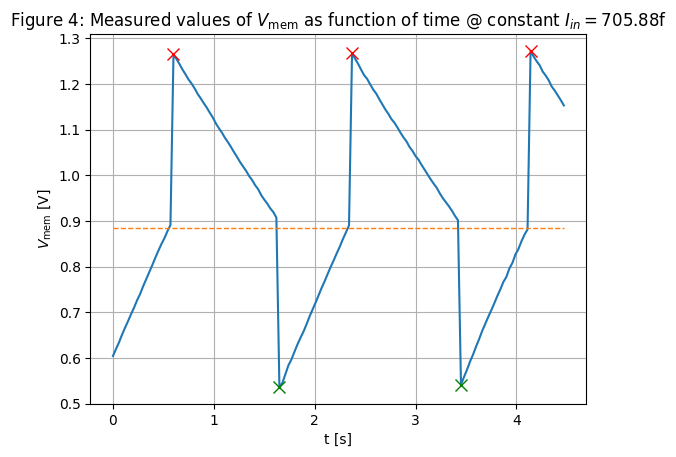

In [23]:
plt.plot(t, Vcm)
plt.plot(pos_peaks*dT, Vcm[pos_peaks], "rx", markersize=8)
plt.plot(neg_peaks*dT, Vcm[neg_peaks], "gx", markersize=8)
plt.plot(t, np.ones(N_samples)*Vthr, "--", linewidth=1)
plt.xlabel('t [s]')
plt.ylabel('$V_{\\rm mem}$ [V]')
plt.title(f'Figure 4: Measured values of $V_{{\\rm mem}}$ as function of time @ constant $I_{{in}} = ${ef(Ib)}')
plt.grid()
plt.show()

In [24]:
# if the data looks nice, save it!
savevars(datapath/'3_1_ahn-eq')

[INFO]: 2025-11-17 09:59:57,918 - saveloadvars - Saved to data/neuron/3_1_ahn-eq.dill variables [ datapath Ib N_samples dT t Vcm i fun_thr Vthr Cmem idx dvdt Iin pos_peaks neg_peaks Vpeak_pos Vpeak_neg tL tH Cgs ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-17 09:59:57,919 - saveloadvars - could not pickle: ['c', 'discontinuities_idx'] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'ahn-eq')

## 3.2 Different pulse widths

We've shown in the previous section how the intensity or $I_{\rm rst}$ affects the width
of the spike generated at the output of the circuit.

Now <font color=#108ee9> experiment with different values for $I_{\rm rst}$ </font> as your
liking.

In [25]:
fine_values = [1, 5, 10, 50]

In [26]:
N_samples = 150
dT = 0.03

n_fines = len(fine_values)

t = np.arange(N_samples)*dT
Vcm = np.zeros((N_samples, n_fines))

for idx, f in tqdm(enumerate(fine_values)):
    _ = c.set_ahn_vpw_ib(pyplane.Coach.BiasGenMasterCurrent.I60pA, f)
    
    for i in range(N_samples):
        Vcm[i, idx] = c.read_ahn_vout()
        time.sleep(dT)

4it [00:20,  5.17s/it]


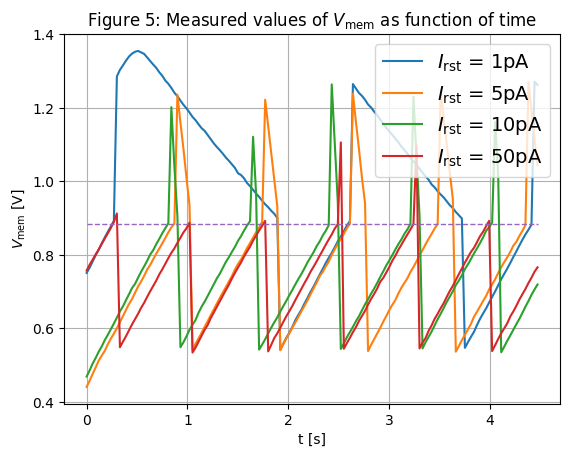

In [27]:
for idx, f in enumerate(fine_values):
    plt.plot(t, Vcm[:, idx])
plt.plot(t, np.ones(N_samples)*Vthr, "--", linewidth=1)
plt.xlabel("t [s]")
plt.ylabel("$V_{\\rm mem}$ [V]")
plt.title(f'Figure 5: Measured values of $V_{{\\rm mem}}$ as function of time')
plt.legend(
    [f"$I_{{\\rm rst}}$ = {ef(f)}pA" for f in fine_values],
    prop={'size': 14}
)
plt.grid()
plt.show()

## 3.3 Switch off the circuit

* To avoid the output events interfering with other circuits, we set `AHN_VPW_N` to maximum again. 

In [28]:
# disable axon-hillock neuron
_ = c.set_ahn_vpw_ib(pyplane.Coach.BiasGenMasterCurrent.I60pA, 0)

# 4 Basic behavoir of classic current-mode adaptive integrate and fire neuron

The **ADEXIF** (Adaptive Exponential Integrate & Fire) **classic neuron** comprises
four major functional blocks:
* **Leaky DPI** *(integrate)*
* **Starved Inverter** *(fire)*
* **Refractory period** *(reset)* 
* **Adaptation**

The adaptation block receives the spike pulse of the neuron itself through a pulse extender circuit. Notice that the **`PEX`** block receives `ACN_REQ_ASO` as input, which is
also the output of the whole neuron.

The circuit receives an input current $I_{in}$ (typically the output of a synapse, $I_{syn}$)
 on `ACN_IIIN_UI` and outputs an AER event.
The membrane voltage $V_{\rm mem}$ is provided to observe the internal neuron state at
**`ADC[10]`**.

The circuit behaviour can be controlled through multiple values:
* The neuron circuit has 4 basic biases: $V_{\rm dc}$, $V_{\rm gain}$,
$V_{\rm leak}$ and $V_{\rm refr}$
* The adaptation block has 5 more biases: $V_{\rm adp, gain}$, $V_{\rm adpw, eight}$,
$V_{\rm adp, tau}$, $V_{\rm adp, casc}$ & $V_{\rm adp, ptau}$ (for the pulse extender)
* There are furthermore two digital control bits:
    - $V_{\rm adp, en}$ to enable/disable adaptation
    - $V_{\rm dc, en}$ to disable/enable the $V_{\rm dc}$ bias input

The important capacitances of the circuit are as follows:
$$
\begin{alignedat}{3}
    &C_{\rm mem} &&= 2\text{pF}
    \\[0.75em]
    &C_{\rm refr} &&= 1\text{pF}
    \\[0.75em]
    &C_{\rm adp} &&= 1\text{pF}
\end{alignedat}
$$

<div id="fig:02:wta-schematic"
    style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">
    
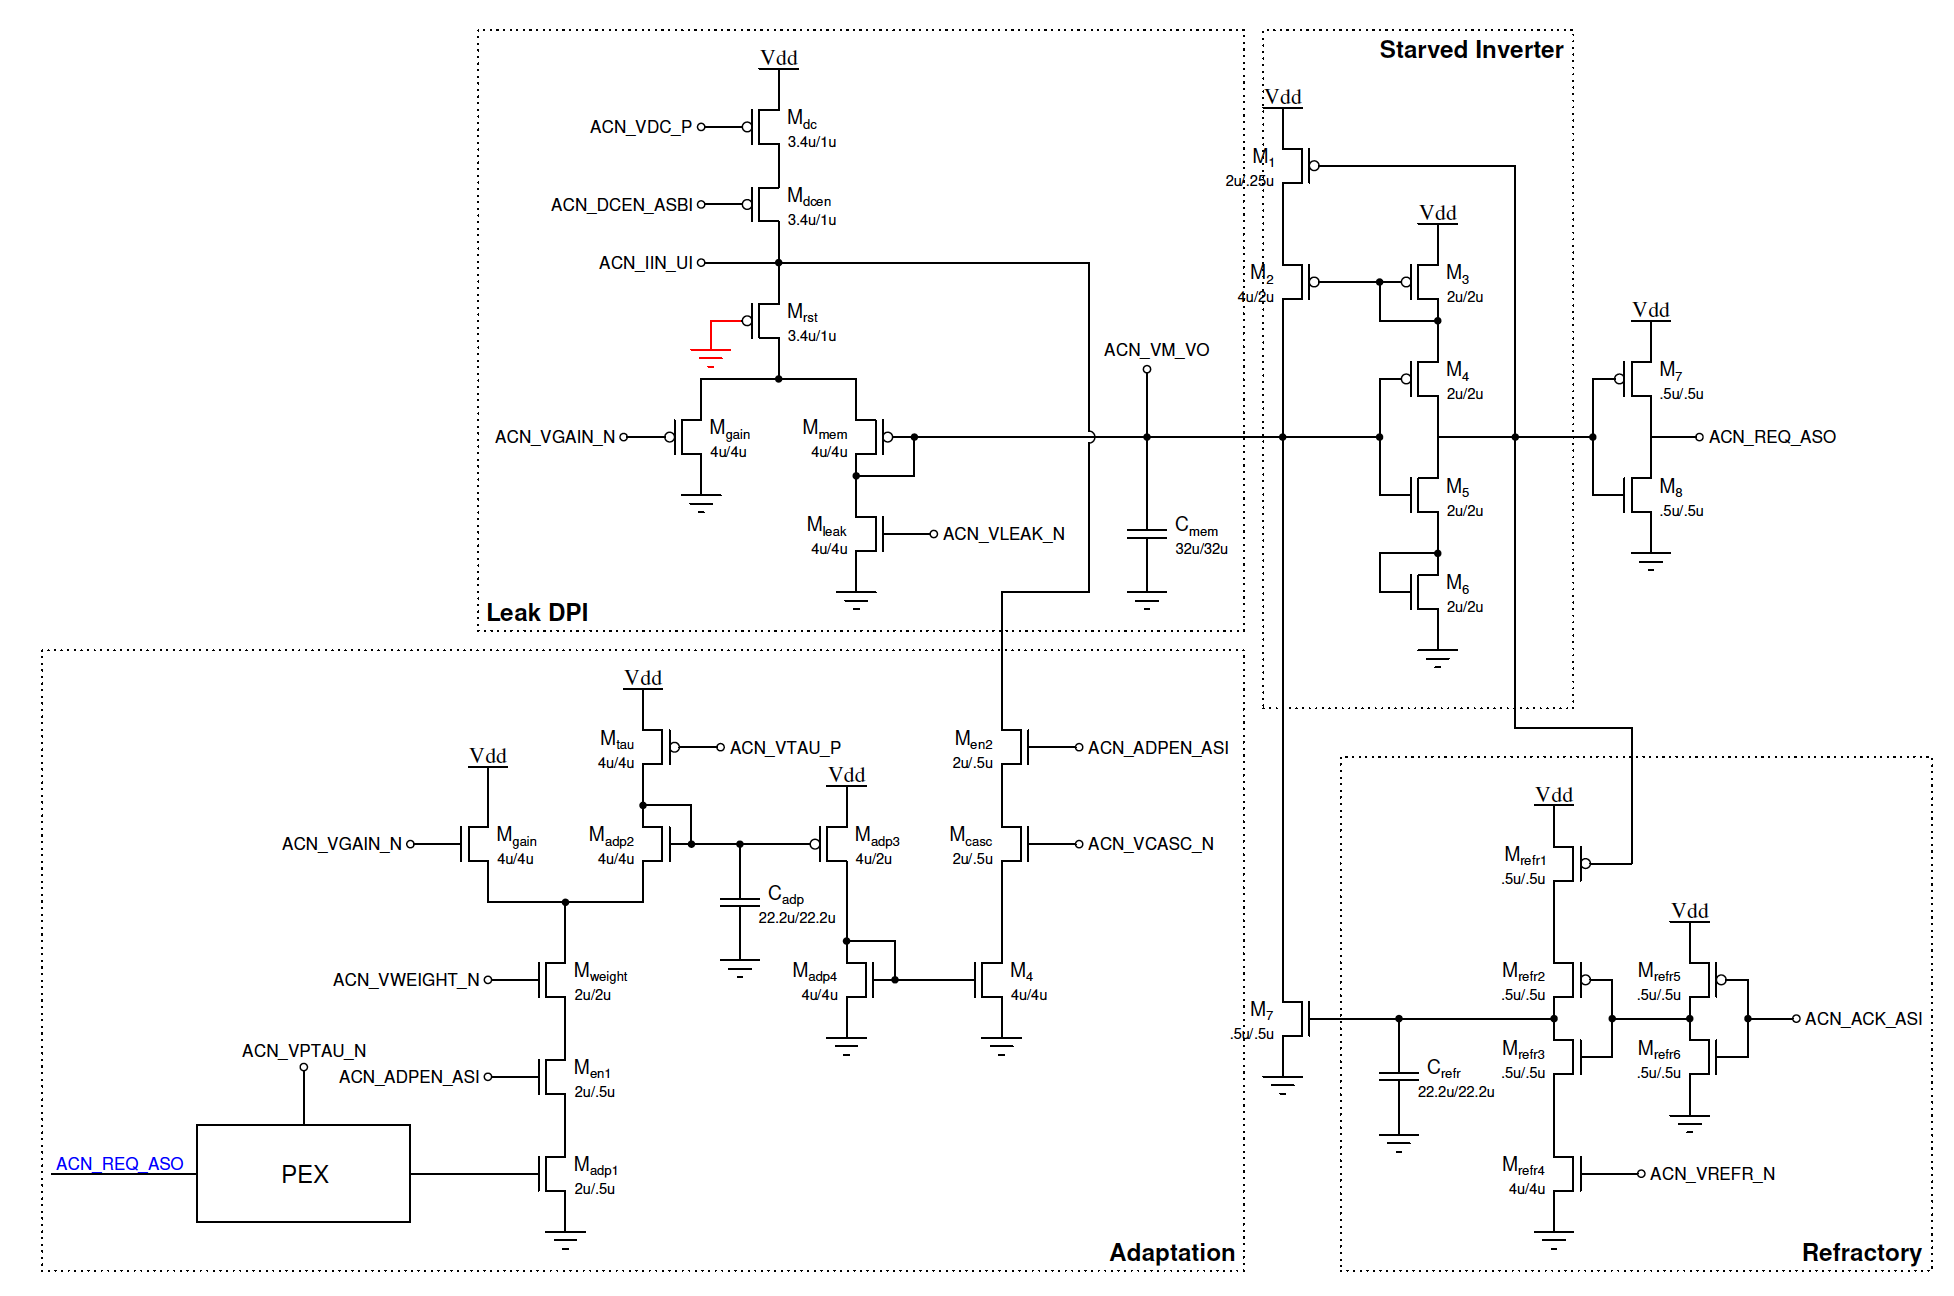

**Figure 6**: Schematic of the I&F neuron circuit present on the CoACH board

</div>

## 4.1 Basic measurement

In [29]:
c.setup_ief()

[INFO]: 2025-11-17 10:01:27,524 - NE1 - setup I&F neuron (File "/Users/mariusfauteux/Documents/NE1-CoACH-LABS/ne1.py", line 1654, in setup_ief)


* Read the response of the circuit at constant input current. Record for $250\mu s$.

In [30]:
Vmem = c.read_i2f_transient_vout(0.00025, 1)

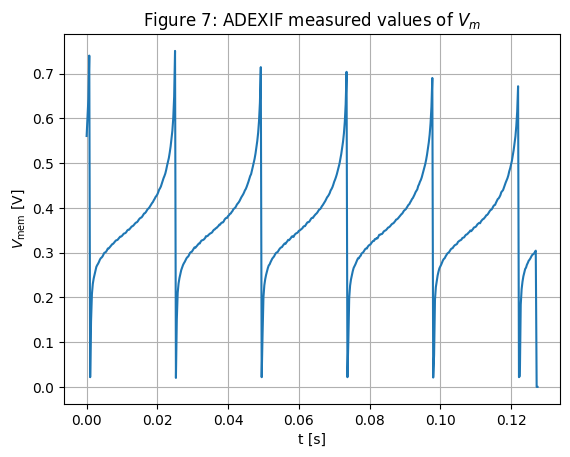

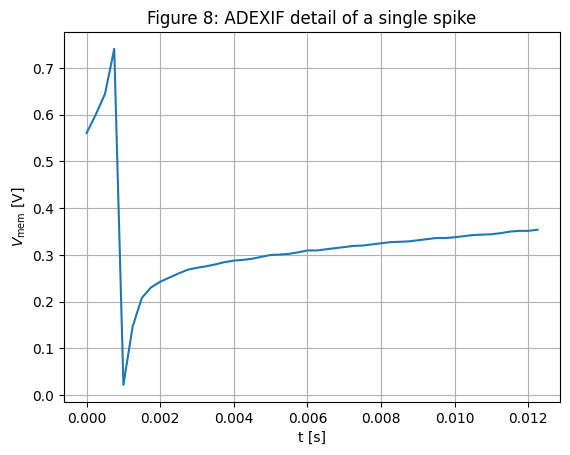

In [31]:
t_sample = 0.00025
n_samples = len(Vmem)

t = np.arange(n_samples) * t_sample

plt.plot(t, Vmem)
plt.xlabel('t [s]')
plt.ylabel('$V_{\\rm mem}$ [V]')
plt.title("Figure 7: ADEXIF measured values of $V_m$")
plt.grid()
plt.show()

# change this if you don't properly see the spike
n_samples_fine = 50

t_fine = np.arange(n_samples_fine) * t_sample
plt.plot(t_fine, Vmem[:n_samples_fine])
plt.xlabel('t [s]')
plt.ylabel('$V_{\\rm mem}$ [V]')
plt.title("Figure 8: ADEXIF detail of a single spike")
plt.grid()
plt.show()

In [32]:
savevars(datapath/'full_lab')

[INFO]: 2025-11-17 10:02:04,347 - saveloadvars - Saved to data/neuron/full_lab.dill variables [ datapath Ib N_samples dT t Vcm i fun_thr Vthr Cmem idx dvdt Iin pos_peaks neg_peaks Vpeak_pos Vpeak_neg tL tH Cgs fine_values n_fines f Vmem t_sample n_samples n_samples_fine t_fine ] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-17 10:02:04,347 - saveloadvars - could not pickle: ['c', 'discontinuities_idx'] (File "/Users/mariusfauteux/Documents/CoACH-labs/.conda/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


## 4.2 Have fun!

By now you should understand how play around with the circuits present on the board.

There are a lot of parameters you can change for the I&F neuron circuit that, if you understood the theory
behind it, should lead to quite interesting results.

Feel free to play around and copy any preceding code cell to help you.

## 5 Postlab

* <font color=#108ee9> What is the reason nature evolved biological neurons to show a refractory period? </font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

</div>

* <font color=#108ee9> Do you think this phenomenon carries computational information? </font>
  *(ie can we ignore it in our model and still believe to follow biological inspiration)* Hint: recall that the DVS pixel also has a refractory period that plays a critical role in limiting the maximum brightness change event rate. It can be used on DVS cameras to limit the maximum event rate that otherwise might saturate the AER output bus or the processor of the events. It also has the useful property that changing it does not create events and so it is the most practical way to apply [automatic feedback control of the event camera output data rate](https://ieeexplore.ieee.org/document/9522899). However making a big refractory period has a penalty of discarding incoming current during it. So it throws away possibly useful information.
  Is it possible that the nervous system might do something similar?

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

</div>

## What we expect you to learn
Please see the [NE1 exam preparation guide](https://drive.google.com/file/d/1nOq3UbcEv_ik425VBYqcH9hAET7FyIeP/view?usp=drive_link)
